In [1]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.models.ODEWrapper import ODEWrapper
from lincs_gsnn.data.DXDTDataset import DXDTDataset

from gsnn.interpret.utils import plot_edge_importance

from lincs_gsnn.explain.topology import adjust_for_topology
from lincs_gsnn.explain.topology import topology_baseline_score
from lincs_gsnn.proc.node_activity import load_node_activity_artifact

from lincs_gsnn.explain.utils import generate_masked_trajectories

from lincs_gsnn.explain.eval import eval_traj_diff

import seaborn as sbn 

import networkx as nx

%load_ext autoreload
%autoreload 2


# Trametinib and DUSP6

target_gene: 'DUSP6'  
cell_line_1: 'MDA-MB-231'  
cell_line_2: 'MCF7'  
pert_id: 'BRD-K12343256'  

In [2]:
EXP_NAME = 'trametinib_mapk'
ROOT_NAME = 'exp_37'

root = f'/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/{ROOT_NAME}'
save_dir = f'/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/{ROOT_NAME}/notebook_{EXP_NAME}/'
os.makedirs(save_dir, exist_ok=True)

cres = pd.read_csv(f'{root}/contrastive_explanation_{EXP_NAME}/aggregated_cres.csv')
out_dict = torch.load(f'{root}/contrastive_explanation_{EXP_NAME}/aggregated_out_dict.pt', weights_only=False)

data = torch.load(os.path.join(root, 'bionetwork/bionetwork.pt'), weights_only=False)

TARGET_GENE = 'DUSP6'
CELL_LINE_1 = 'MDA-MB-231'
CELL_LINE_2 = 'MCF7'
DRUG_ID = 'TRAMETINIB'
INCLUSION_THRESHOLD = 0.5 

# Expected high importance nodes. # MEKs, ERKs, ETS1 
INVOLVED_NODES = ['PROTEIN__MAP2K1',
                    'PROTEIN__MAP2K2',
                    'PROTEIN__MAPK1',
                    'PROTEIN__MAPK3',
                    'PROTEIN__ETS1',
                    ]

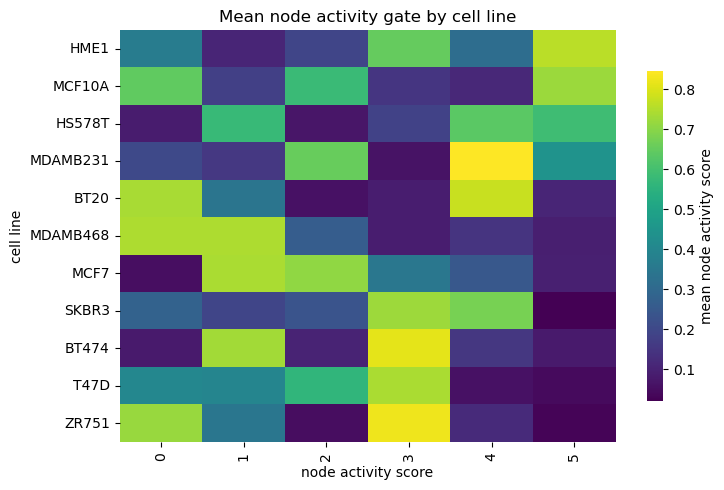

In [3]:
from lincs_gsnn.explain.eval import eval_node_activity

root_traj = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/'
nadf_vars, nadf_corrs = eval_node_activity(root_gsnn=root, root_traj=root_traj, model_id='model_0', plot=True, save_dir=None)


# Plot the trajectory diffference between the two cell lines of interest

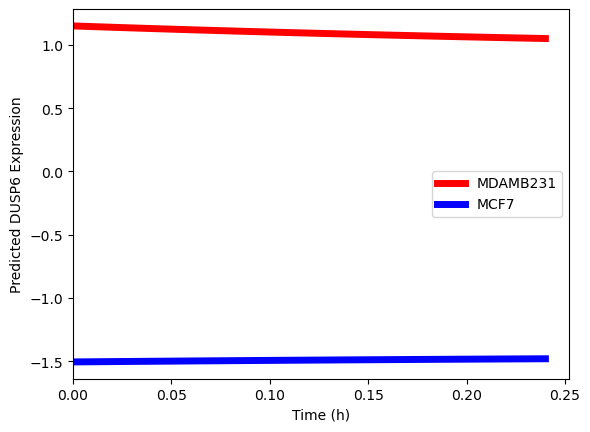

In [4]:
alpha = 0.2
linewidth = 5

gsnn_trajs_x1 = [] 
gsnn_trajs_x2 = [] 
for sample_id, sample_dict in out_dict.items():

    gsnn_trajs_x1.append(sample_dict['xt_hat_1'][:, sample_dict['target_gene_output_ix']])
    gsnn_trajs_x2.append(sample_dict['xt_hat_2'][:, sample_dict['target_gene_output_ix']])

gsnn_trajs_x1 = np.stack(gsnn_trajs_x1, axis=0) 
gsnn_trajs_x2 = np.stack(gsnn_trajs_x2, axis=0) 

plt.figure() 
for i in range(gsnn_trajs_x1.shape[0]):
    plt.plot(out_dict['model_0']['t'], gsnn_trajs_x1[i], 'r--', alpha=alpha)
    plt.plot(out_dict['model_0']['t'], gsnn_trajs_x2[i], 'b--', alpha=alpha)

plt.plot(out_dict['model_0']['t'], gsnn_trajs_x1.mean(axis=0), 'r-', linewidth=linewidth, label=out_dict['model_0']['cell_line_1']) # make dark red 
plt.plot(out_dict['model_0']['t'], gsnn_trajs_x2.mean(axis=0), 'b-', linewidth=linewidth, label=out_dict['model_0']['cell_line_2'])

plt.xlabel('Time (h)')
plt.ylabel(f'Predicted {TARGET_GENE} Expression')
plt.legend()

plt.xlim(0)

plt.savefig(f'{save_dir}/{EXP_NAME}_traj_diff_{CELL_LINE_1}_{CELL_LINE_2}_{TARGET_GENE}.png', dpi=300)    
plt.show()




/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


MDA-MB-231: AUC(change) mean = -2.6632, std = 0.0000, n = 1
MCF7: AUC(change) mean = 0.6668, std = 0.0000, n = 1
auc_diff (auc1 - auc2): mean = -3.3300, std = 0.0000
Welch one-sided t-test (H1: mean(MDA-MB-231) < mean(MCF7)): p = nan


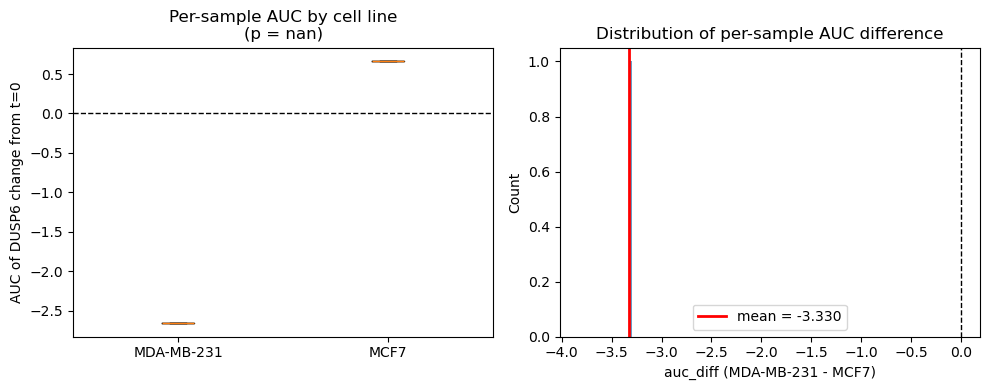

In [5]:

auc1, auc2, auc_diff, pvalue = eval_traj_diff(
    f'{root}/contrastive_explanation_{EXP_NAME}'
)

print(f'{CELL_LINE_1}: AUC(change) mean = {auc1.mean():.4f}, std = {auc1.std():.4f}, n = {auc1.size}')
print(f'{CELL_LINE_2}: AUC(change) mean = {auc2.mean():.4f}, std = {auc2.std():.4f}, n = {auc2.size}')
print(f'auc_diff (auc1 - auc2): mean = {auc_diff.mean():.4f}, std = {auc_diff.std():.4f}')
print(f'Welch one-sided t-test (H1: mean({CELL_LINE_1}) < mean({CELL_LINE_2})): p = {pvalue:.3e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot([auc1, auc2], tick_labels=[CELL_LINE_1, CELL_LINE_2])
axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0].set_ylabel(f'AUC of {TARGET_GENE} change from t=0')
axes[0].set_title(f'Per-sample AUC by cell line\n(p = {pvalue:.2e})')

axes[1].hist(auc_diff, bins=30, color='steelblue', alpha=0.8)
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].axvline(auc_diff.mean(), color='r', linestyle='-', linewidth=2, label=f'mean = {auc_diff.mean():.3f}')
axes[1].set_xlabel(f'auc_diff ({CELL_LINE_1} - {CELL_LINE_2})')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of per-sample AUC difference')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/{EXP_NAME}_auc_diff_{CELL_LINE_1}_{CELL_LINE_2}_{TARGET_GENE}.png', dpi=300)
plt.show()



# ContrastiveGSNNExplainer (CGE) result statistics 

In [6]:
cres.head() 

,source,target,ig_score_model_0,gsnn_score_model_0,occlusion_score_model_0
0,COMPLEX__BTRC_CUL1_SKP1,PROTEIN__CTNNB1,-6.934607e-06,0.651038,1.383722e-06
1,COMPLEX__CCNH_CDK7_MNAT1,PROTEIN__CDK7,9.869449e-05,0.957659,-3.199682e-05
2,COMPLEX__FOSL2_JUND,RNA__hsa-miR-21,4.021854e-07,0.771877,1.013279e-08
3,COMPLEX__PRKAA1_PRKAA2_PRKAB1_PRKAB2_PRKAG1_PR...,PROTEIN__TP53,-1.595144e-04,0.997737,-1.406166e-04
4,DRUG__ALVOCIDIB,PROTEIN__CDK7,2.375934e-04,0.988318,3.221750e-05


quantiles:  [3115. 3115. 3115. 3115. 3115.]


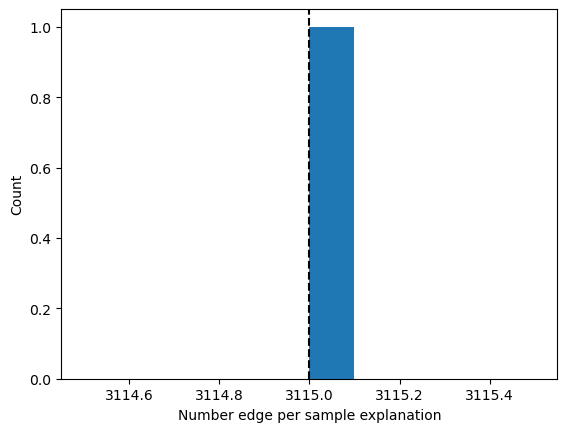

In [7]:
gsnn_sample_names = [x for x in cres.columns if 'gsnn_score_model' in x]

cge_cres = cres[['source', 'target'] + gsnn_sample_names] 

included_edges_per_sample = (cge_cres.values[:, 2:] > INCLUSION_THRESHOLD).sum(axis=0)

print('quantiles: ', np.quantile(included_edges_per_sample, [0, 0.025, 0.5, 0.975, 1]))

plt.figure() 
plt.hist(included_edges_per_sample, bins=10)
plt.xlabel('Number edge per sample explanation')
plt.ylabel('Count')
plt.axvline(np.mean(included_edges_per_sample), color='k', linestyle='--')
plt.show()

# Load and aggregate explanations

In [8]:
from lincs_gsnn.explain.eval import agg_node_scores

path = f'{root}/non_contrastive_explanation_{EXP_NAME}_node_target__{CELL_LINE_1.replace("-", "")}/aggregated_cres.csv'
node_df = agg_node_scores(path, fill_value=np.nan)
node_df.head() 

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
0,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,0.004685,0.0,0.0
1,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,0.004085,0.0,0.0
2,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,0.004165,0.0,0.0
3,COMPLEX__APC_AXIN1_GSK3B,0.004733,0.0,0.0
4,COMPLEX__APC_CDC20,0.005076,0.0,0.0


In [9]:
from lincs_gsnn.explain.eval import agg_edge_scores

path = f'{root}/non_contrastive_explanation_{EXP_NAME}__{CELL_LINE_1.replace("-", "")}/aggregated_cres.csv'
edge_df = agg_edge_scores(path, fill_value=np.nan)
edge_df = edge_df.sort_values(by='mean_oc_score', ascending=False)
edge_df.head() 

,source,target,mean_gsnn_score,std_gsnn_score,mean_ig_score,std_ig_score,mean_oc_score,std_oc_score,abs_ig_score,abs_oc_score
29964,RNA__DUSP6,GENE__DUSP6,0.999850,0.0,1.438440,0.0,1.341977,0.0,1.438440,1.341977
5543,GENE__DUSP6,RNA__DUSP6,0.998002,0.0,-0.047045,0.0,0.238363,0.0,0.047045,0.238363
12505,PROTEIN__ETS1,RNA__DUSP6,0.997958,0.0,-0.235884,0.0,0.107057,0.0,0.235884,0.107057
770,DRUG__oe_DUSP6,RNA__DUSP6,0.999049,0.0,0.197429,0.0,0.097194,0.0,0.197429,0.097194
24320,PROTEIN__SOX13,RNA__DUSP6,0.996701,0.0,0.066988,0.0,0.069896,0.0,0.066988,0.069896


# Regulator Contributions 

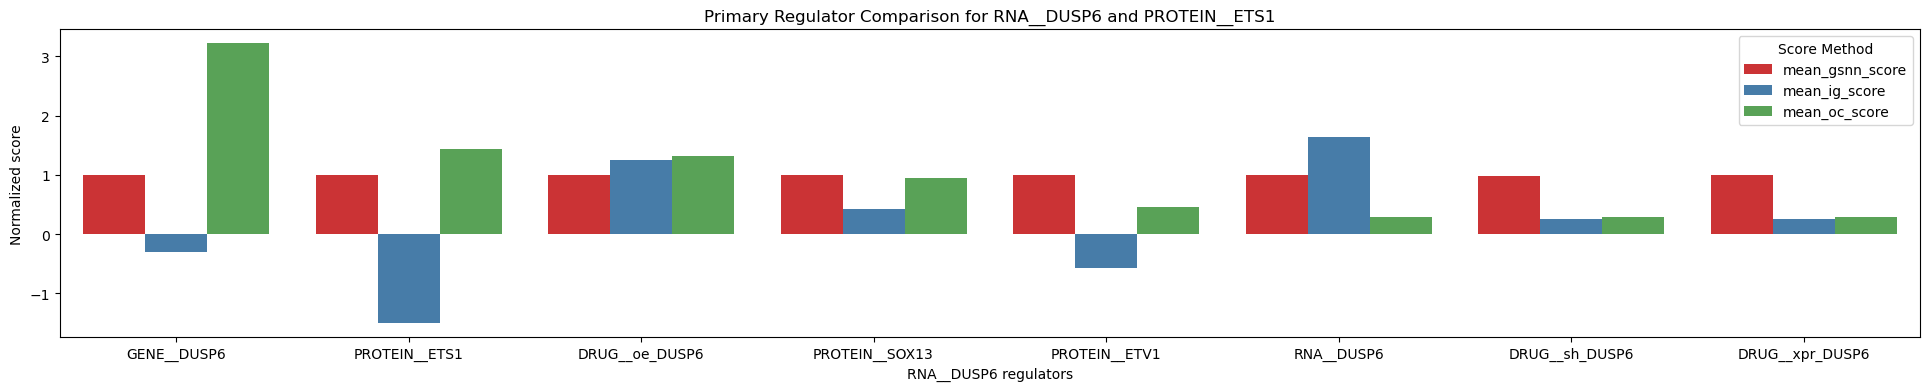

{'gsnn_rank': 3,
 'ig_rank': 1,
 'oc_rank': 7,
 'num_regulators': 8,
 'target_node': 'RNA__DUSP6',
 'expected_regulator': 'PROTEIN__ETS1',
 'expected_direction': 'negative'}

In [10]:
from lincs_gsnn.explain.eval import primary_regulator_comparison

reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'RNA__{TARGET_GENE}', 
                                        expected_regulator='PROTEIN__ETS1', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

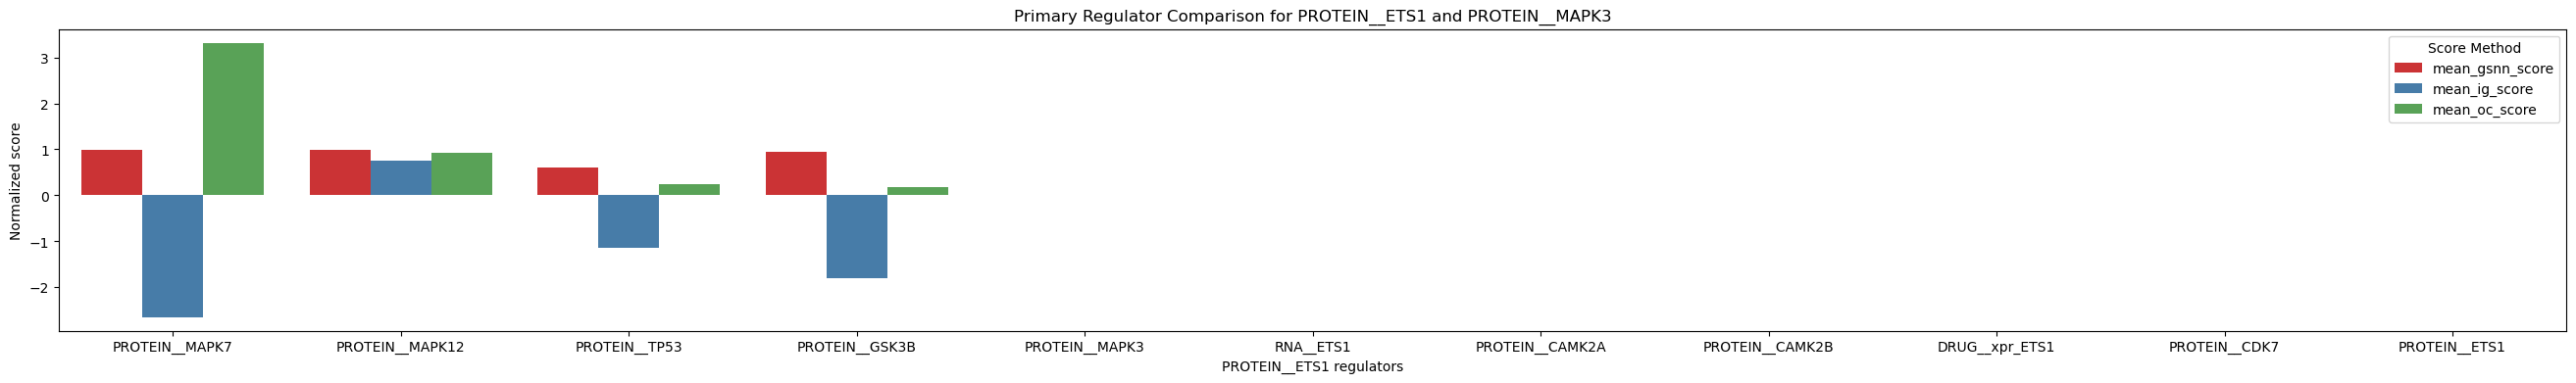

{'gsnn_rank': 10,
 'ig_rank': 10,
 'oc_rank': 7,
 'num_regulators': 11,
 'target_node': 'PROTEIN__ETS1',
 'expected_regulator': 'PROTEIN__MAPK3',
 'expected_direction': 'negative'}

In [11]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__ETS1', 
                                        expected_regulator='PROTEIN__MAPK3', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

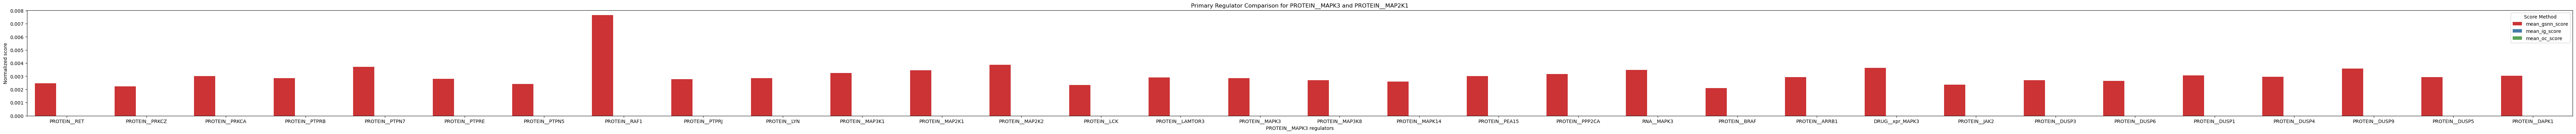

{'gsnn_rank': 7,
 'ig_rank': 32,
 'oc_rank': 32,
 'num_regulators': 32,
 'target_node': 'PROTEIN__MAPK3',
 'expected_regulator': 'PROTEIN__MAP2K1',
 'expected_direction': 'negative'}

In [12]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__MAPK3', 
                                        expected_regulator='PROTEIN__MAP2K1', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

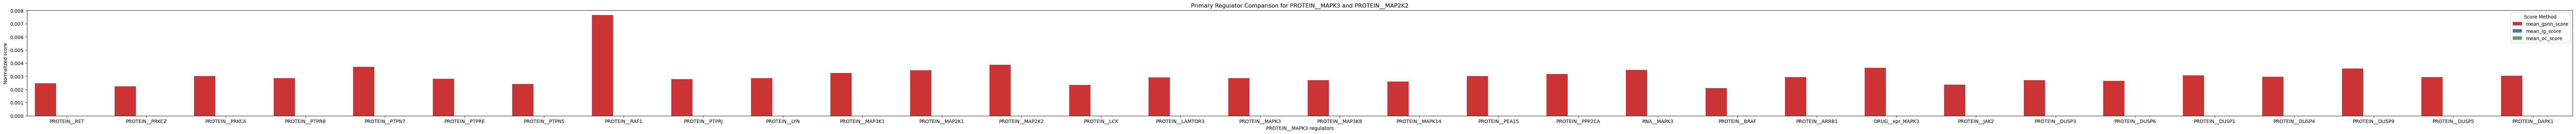

{'gsnn_rank': 2,
 'ig_rank': 32,
 'oc_rank': 32,
 'num_regulators': 32,
 'target_node': 'PROTEIN__MAPK3',
 'expected_regulator': 'PROTEIN__MAP2K2',
 'expected_direction': 'negative'}

In [13]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__MAPK3', 
                                        expected_regulator='PROTEIN__MAP2K2', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

# Node ranking comparion

In [14]:
node_df.sort_values(by='mean_gsnn_score', ascending=False).head(10)

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
7795,RNA__DUSP6,0.999320,0.562801,0.562805
534,DRUG__oe_IL1B,0.006326,0.000000,0.000000
2556,DRUG__xpr_BACE2,0.006323,0.000000,0.000000
4902,PROTEIN__ADCY5,0.006257,0.000000,0.000000
1750,DRUG__sh_LHX2,0.006220,0.000000,0.000000
9472,RNA__TMEM50A,0.006177,0.000000,0.000000
6437,PROTEIN__PKNOX1,0.006146,0.000000,0.000000
6555,PROTEIN__PTGER3,0.006078,0.000000,0.000000
5958,PROTEIN__KEAP1,0.006049,0.000000,0.000000
9113,RNA__RING1,0.006039,0.000000,0.000000


In [15]:
from lincs_gsnn.explain.eval import data2nx, node_ranking_comparison

G = data2nx(data)

INVOLVED_NODES = [ 'PROTEIN__MAP2K1', 'PROTEIN__MAP2K2', 'PROTEIN__MAPK3', 'PROTEIN__ETS1', 'RNA__DUSP6']

mrr_node, node_rank_df = node_ranking_comparison(node_df=node_df, 
                                            G=G, 
                                            target_node=f'RNA__{TARGET_GENE}', 
                                            source_node=f'DRUG__{DRUG_ID}', 
                                            expected_nodes=INVOLVED_NODES, 
                                            expected_direction='negative')


generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...


In [16]:
node_rank_df.head() 

,node,gsnn_rank,ig_rank,oc_rank,rw_rank,pr_rank,rwb_rank,bc_rank
5530,PROTEIN__ETS1,5158.0,9764.0,9764.0,7.0,6.0,36.0,3.0
6069,PROTEIN__MAP2K1,13.0,9764.0,9764.0,4.0,3.0,5.0,5.0
6070,PROTEIN__MAP2K2,7776.0,9764.0,9764.0,8.0,5.0,4.0,7.0
6102,PROTEIN__MAPK3,9299.0,9764.0,9764.0,1.0,1.0,7.0,5.0
7795,RNA__DUSP6,1.0,9765.0,9765.0,13.0,12.0,2.0,3.0


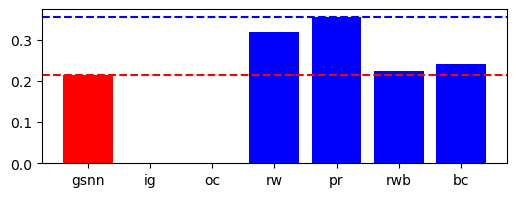

In [17]:
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_node.columns, mrr_node.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_node[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_node[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


# Edge ranking comparison 

In [18]:
from lincs_gsnn.explain.eval import edge_ranking_comparison

EXPECTED_EDGES = pd.DataFrame({'source': ['DRUG__BRD-K12343256', 'DRUG__BRD-K12343256', 'PROTEIN__MAP2K1', 'PROTEIN__MAP2K2', 'PROTEIN__MAPK3', 'PROTEIN__ETS1'], 
                               'target': ['PROTEIN__MAP2K2', 'PROTEIN__MAP2K1', 'PROTEIN__MAPK3', 'PROTEIN__MAPK3', 'PROTEIN__ETS1', 'RNA__DUSP6']})

mrr_edge, edge_rank_df = edge_ranking_comparison(edge_df=edge_df, 
                                                G=G, 
                                                source_node=f'DRUG__{DRUG_ID}', 
                                                target_node=f'GENE__{TARGET_GENE}', 
                                                expected_edges=EXPECTED_EDGES)

edge_rank_df 

generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...


source,target,gsnn_rank,ig_rank,oc_rank,rw_rank,pr_rank,rwb_rank,bc_rank
PROTEIN__ETS1,RNA__DUSP6,4,1,34441,60,39,13,2
PROTEIN__MAP2K1,PROTEIN__MAPK3,3818,34435,34422,4,4,19,9
PROTEIN__MAP2K2,PROTEIN__MAPK3,608,34435,34422,1,1,13,9
PROTEIN__MAPK3,PROTEIN__ETS1,1441,34435,34422,7,7,19,4


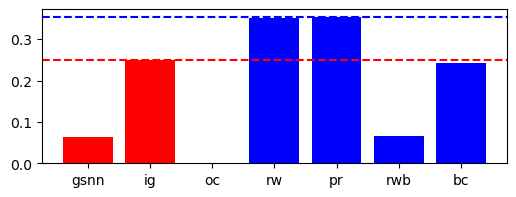

In [19]:
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_edge.columns, mrr_edge.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_edge[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_edge[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


# Path ranking comparison 

In [20]:
from lincs_gsnn.explain.eval import path_ranking_comparison

EXPECTED_PATHS = [
                  'MAP2K1 -> MAPK3 -> ETS1 -> DUSP6', 
                  'MAP2K2 -> MAPK3 -> ETS1 -> DUSP6',
                  ]

mrr_path, path_rank_df = path_ranking_comparison(path_df=edge_df, 
                                                G=G, 
                                                source_node=f'DRUG__{DRUG_ID}', 
                                                target_node=f'GENE__{TARGET_GENE}', 
                                                expected_paths=EXPECTED_PATHS, 
                                                expected_direction='negative', 
                                                max_path_length=6)

path_rank_df 

generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...
adding edge attributes to G...
scoring paths (product) ...
scoring paths (sum) ...
scoring paths (mean) ...


,path_short,mean_gsnn_score_product_rank,mean_ig_score_sum_rank,mean_oc_score_sum_rank,rw_score_sum_rank,pr_score_sum_rank,rwb_score_sum_rank,bc_score_sum_rank
2,MAP2K1 -> MAPK3 -> ETS1 -> DUSP6,4.0,16.0,21.0,14.0,14.0,31.0,1.0
20,MAP2K2 -> MAPK3 -> ETS1 -> DUSP6,11.0,16.0,21.0,1.0,1.0,18.0,5.0


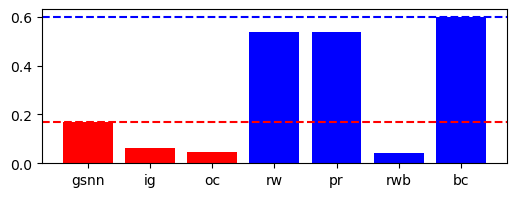

In [21]:
mrr_path = mrr_path.rename(columns={'mean_gsnn_score_product': 'gsnn', 
                                    'mean_ig_score_sum': 'ig', 
                                    'mean_oc_score_sum': 'oc', 
                                    'rw_score_sum': 'rw', 
                                    'pr_score_sum': 'pr', 
                                    'rwb_score_sum': 'rwb', 
                                    'bc_score_sum': 'bc'})
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_path.columns, mrr_path.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_path[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_path[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


---
# Subgraph Explanation Plot 
---

In [22]:
FILTER_TO_DRUG = False
TARGET_NAME = f'RNA__{TARGET_GENE}'
DRUG_NAME = f'DRUG__{DRUG_ID}'
CELL_LINE_1 = out_dict["model_0"]["cell_line_1"]
CELL_LINE_2 = out_dict["model_0"]["cell_line_2"]

TOP_N_NODES = 100
REMOVE_CELL___EDGES = True
REMOVE_GENE___EDGES = True
PROB_FILTER_THRESH = 0.0

CLIP_SCORE = True
CLIP_VALUE = 10

SCALE_SCORE = True
MIN_SCORE = -1
MAX_SCORE = 1

FILTER_BY_SCORE = 'abs_oc_score'
COLOR_BY_SCORE = 'mean_oc_score' # options: 'mean_ig_score', 'mean_oc_score', 'mean_gsnn_score'\

FIGSIZE = (13,11)
INTERACTIVE = False

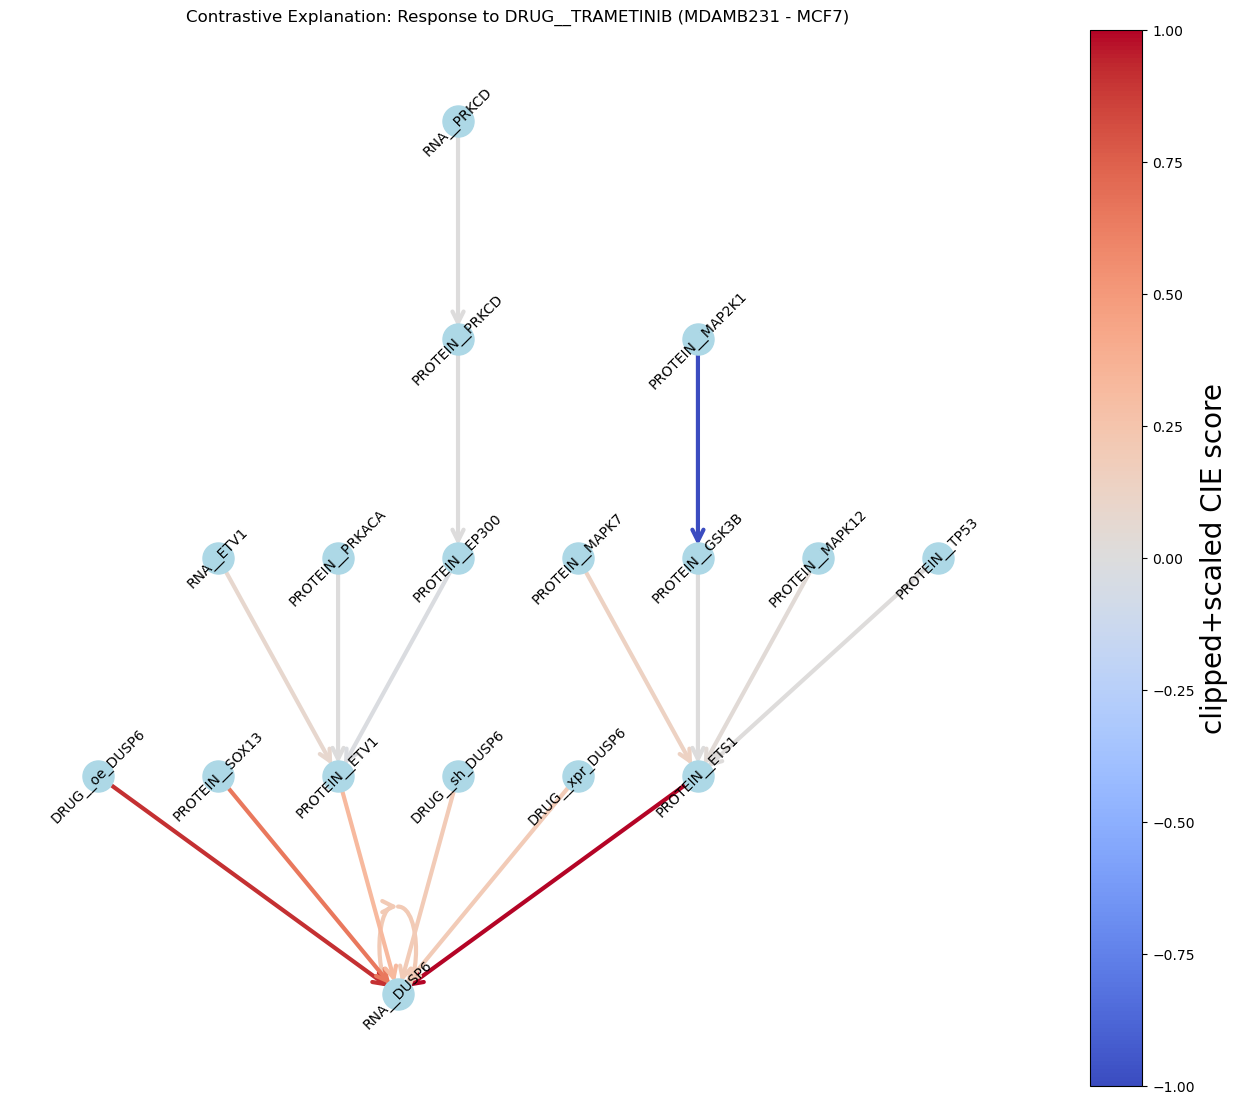

In [23]:

ccres = edge_df.reset_index().assign(**{'score': lambda x: x[COLOR_BY_SCORE],
                                        'abs_ig_score': lambda x: np.abs(x.mean_ig_score),
                                        'abs_oc_score': lambda x: np.abs(x.mean_oc_score)})[['source', 'target', 'score', FILTER_BY_SCORE]]

if REMOVE_CELL___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))]

if REMOVE_GENE___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('GENE__') | x.target.str.contains('GENE__'))]

ccres = ccres[ccres[FILTER_BY_SCORE] > PROB_FILTER_THRESH]

ccres = ccres.sort_values(by=FILTER_BY_SCORE, ascending=False).head(TOP_N_NODES)

# SCALING FOR COLOR DISPLAY
if CLIP_SCORE: 
    ccres = ccres.assign(score = lambda x: x.score.values.clip(-CLIP_VALUE, CLIP_VALUE))

if SCALE_SCORE:
    # Scale by absolute max so 0 stays at 0 and signs are preserved
    abs_max = ccres.score.abs().max()
    ccres.loc[ccres.score < 0, 'score'] = ccres.loc[ccres.score < 0, 'score'] / np.abs(ccres.loc[ccres.score < 0, 'score'].min())
    ccres.loc[ccres.score > 0, 'score'] = ccres.loc[ccres.score > 0, 'score'] / np.abs(ccres.loc[ccres.score > 0, 'score'].max())

if INTERACTIVE: 
    figsize = (10, 10)
else: 
    figsize = FIGSIZE

plot_edge_importance(ccres, 
                     figsize=figsize, 
                     leafs=[TARGET_NAME], 
                     roots=[DRUG_NAME] if FILTER_TO_DRUG else None,
                     title=f'Contrastive Explanation: Response to {DRUG_NAME} ({CELL_LINE_1} - {CELL_LINE_2})',
                     interactive=INTERACTIVE, 
                     save=f'{save_dir}/explanation_subgraph_plot_non_interactive_{EXP_NAME}.png',
                     dpi=300, 
                     colorbar_label='clipped+scaled CIE score')



---
# What happens to a given cell line drug response trajectory if we remove node X? 
---

In [24]:
# Trajectory generation logic now lives in
# lincs_gsnn.explain.utils.generate_masked_trajectories
# (called once per cell line for the contrastive case)


In [25]:
NUM_INT_STEPS = 15

root_gsnn = root 
root_traj = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?

drug = DRUG_ID
dose = 10.0

cell1 = out_dict["sample_0"]["cell_line_1"]
cell2 = out_dict["sample_0"]["cell_line_2"]

genes_to_remove = ['PROTEIN__ETS1', 'PROTEIN__ETV1', 'PROTEIN__FOXO3', 'RNA__hsa-miR-181a-5p', 'RNA__hsa-miR-101*', 'RNA__hsa-miR-125b']

target_gene = f'GENE__{TARGET_GENE}'

t = torch.linspace(0, 72, NUM_INT_STEPS)

KeyError: 'sample_0'

In [ ]:
res_all ={} 
for remove_name in genes_to_remove: 
    if remove_name not in data.node_names_dict['function']: 
        continue 
    res_masked = {}
    for sample_ix in [x.split('_')[-1] for x in gsnn_sample_names]:
        print(f'[{remove_name}] - sample {sample_ix}', end='\r')
        sample_id = f'sample_{sample_ix}'
        x1_t_hat, x1_t_hat_nm = generate_masked_trajectories(root_gsnn, root_traj, sample_id=sample_id, target_gene=target_gene, remove_name=remove_name, cell=cell1, drug=drug, dose=dose, t=t)
        x2_t_hat, x2_t_hat_nm = generate_masked_trajectories(root_gsnn, root_traj, sample_id=sample_id, target_gene=target_gene, remove_name=remove_name, cell=cell2, drug=drug, dose=dose, t=t)
        res_masked[sample_id] = {f'{cell1}_masked_{remove_name}': x1_t_hat_nm, 
                                f'{cell2}_masked_{remove_name}': x2_t_hat_nm, 
                                f'{cell1}_all': x1_t_hat, 
                                f'{cell2}_all': x2_t_hat}

    res_all[remove_name] = res_masked 
    print() 


[PROTEIN__ETS1] - sample 0
[PROTEIN__ETV1] - sample 0
[PROTEIN__FOXO3] - sample 0
[RNA__hsa-miR-125b] - sample 0


In [ ]:
diffs_dict = {} 

for remove_name in genes_to_remove: 
    if remove_name not in data.node_names_dict['function']: 
        continue 

    res_masked = res_all[remove_name]

    diffs1 = [] 
    diffs2 = [] 
    for i, sample_id in enumerate(res_masked):
        x1_t_hat, x2_t_hat = res_masked[sample_id][f'{cell1}_all'], res_masked[sample_id][f'{cell2}_all']
        x1_t_hat_nm, x2_t_hat_nm = res_masked[sample_id][f'{cell1}_masked_{remove_name}'], res_masked[sample_id][f'{cell2}_masked_{remove_name}']
        
        diffs1.append(x1_t_hat_nm - x1_t_hat) 
        diffs2.append(x2_t_hat_nm - x2_t_hat) 


    diffs1 = torch.stack(diffs1, dim=0) 
    diffs2 = torch.stack(diffs2, dim=0) 

    diffs_dict[remove_name] = {'diffs1': diffs1, 'diffs2': diffs2}


In [ ]:
ALPHA = 0.1 
TITLE_FONTSIZE = 10
SUPTITLE_FONTSIZE = 12
AXIS_FONTSIZE = 8
f,axes = plt.subplots(1, len(genes_to_remove), figsize=(3*len(genes_to_remove), 3), sharey=True)

plt.suptitle(f'Perturbation: {drug} @ {dose}uM', fontsize=SUPTITLE_FONTSIZE)
for jj, (ax, remove_name) in enumerate(zip(axes, genes_to_remove)): 
    if remove_name not in data.node_names_dict['function']: 
        continue 

    diffs1 = diffs_dict[remove_name]['diffs1']
    diffs2 = diffs_dict[remove_name]['diffs2']

    ax.set_title(f'Masked: {remove_name.split("__")[1]}', fontsize=TITLE_FONTSIZE)
    ax.plot(t, diffs1.mean(dim=0).detach().cpu().numpy(), 'r-', label=f'{cell1}')
    ax.plot(t, diffs2.mean(dim=0).detach().cpu().numpy(), 'b-', label=f'{cell2}')

    for i in range(diffs1.shape[0]):
        ax.plot(t, diffs1[i, :].detach().cpu().numpy(), 'r-', alpha=ALPHA)
        ax.plot(t, diffs2[i, :].detach().cpu().numpy(), 'b-', alpha=ALPHA)

    ax.set_xlabel('Time (h)', fontsize=AXIS_FONTSIZE)
    
    if jj == 0: 
        ax.set_ylabel(f'$\Delta$ {target_gene.split("__")[1]} (unmasked - masked)', fontsize=AXIS_FONTSIZE)

    ax.legend(fontsize=AXIS_FONTSIZE) 

plt.tight_layout()
plt.savefig(f'{save_dir}/trametinib_mapk_diff_masked_{target_gene}.png', dpi=300)
plt.show() 

NameError: name 'genes_to_remove' is not defined

# FOXO3 vs ETS1 expression changes 

In [ ]:
x1_t_hat_foxo3_cell1, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__FOXO3', remove_name=None, cell=cell1, drug=drug, dose=dose, t=t)
x1_t_hat_ets1_cell1, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__ETS1', remove_name=None, cell=cell1, drug=drug, dose=dose, t=t)
x1_t_hat_dusp6_cell1, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__DUSP6', remove_name=None, cell=cell1, drug=drug, dose=dose, t=t)
x1_t_hat_etv1_cell1, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__ETV1', remove_name=None, cell=cell1, drug=drug, dose=dose, t=t)

x1_t_hat_foxo3_cell2, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__FOXO3', remove_name=None, cell=cell2, drug=drug, dose=dose, t=t)
x1_t_hat_ets1_cell2, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__ETS1', remove_name=None, cell=cell2, drug=drug, dose=dose, t=t)
x1_t_hat_dusp6_cell2, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__DUSP6', remove_name=None, cell=cell2, drug=drug, dose=dose, t=t)
x1_t_hat_etv1_cell2, _ = generate_masked_trajectories(root_gsnn, root_traj, sample_id, target_gene='GENE__ETV1', remove_name=None, cell=cell2, drug=drug, dose=dose, t=t)


In [ ]:
# who regulates ETV1? 
G.in_edges('RNA__ETV1')

InEdgeDataView([('GENE__ETV1', 'RNA__ETV1'), ('PROTEIN__SOX2', 'RNA__ETV1'), ('PROTEIN__TAL1', 'RNA__ETV1'), ('PROTEIN__GATA2', 'RNA__ETV1'), ('PROTEIN__SIX2', 'RNA__ETV1'), ('PROTEIN__MEIS2', 'RNA__ETV1'), ('PROTEIN__TCF7L2', 'RNA__ETV1'), ('PROTEIN__MITF', 'RNA__ETV1')])

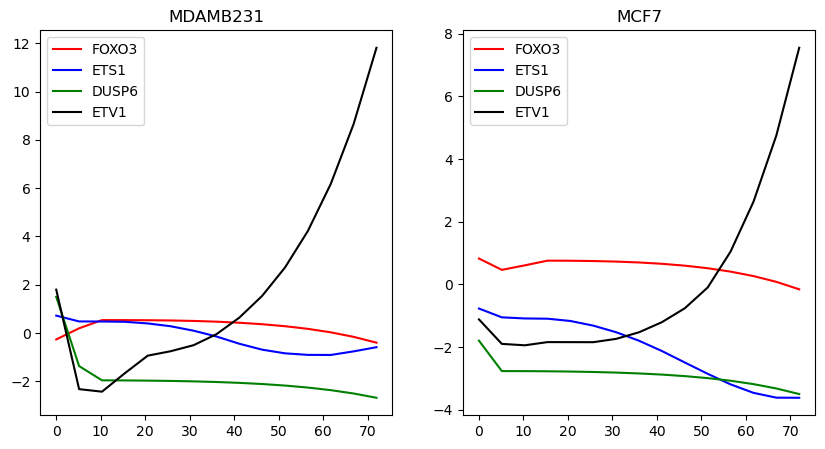

In [ ]:
f,axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(t, x1_t_hat_foxo3_cell1.detach().cpu().numpy(), 'r-', label='FOXO3')
axes[0].plot(t, x1_t_hat_ets1_cell1.detach().cpu().numpy(), 'b-', label='ETS1')
axes[0].plot(t, x1_t_hat_dusp6_cell1.detach().cpu().numpy(), 'g-', label='DUSP6')
axes[0].plot(t, x1_t_hat_etv1_cell1.detach().cpu().numpy(), 'k-', label='ETV1')
axes[0].legend()
axes[0].set_title(f'{cell1}')

axes[1].plot(t, x1_t_hat_foxo3_cell2.detach().cpu().numpy(), 'r-', label='FOXO3')
axes[1].plot(t, x1_t_hat_ets1_cell2.detach().cpu().numpy(), 'b-', label='ETS1') 
axes[1].plot(t, x1_t_hat_dusp6_cell2.detach().cpu().numpy(), 'g-', label='DUSP6')
axes[1].plot(t, x1_t_hat_etv1_cell2.detach().cpu().numpy(), 'k-', label='ETV1')
axes[1].legend()
axes[1].set_title(f'{cell2}')
plt.show() 


# STAT3 Expression impact on DUSP6 response to Trametinib 

In [ ]:
def run(root_gsnn, root_traj, sample_id, target_gene,  cell1, drug, dose, t=torch.linspace(0, 72, 100), x_perturbation=None): 

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
    obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

    # load data 
    data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False, map_location=device)
    model = torch.load(os.path.join(root_gsnn, f'pretrain/pretrained_model_{sample_id}.pt'), weights_only=False, map_location=device)
    dxdt_scale = torch.load(os.path.join(root_gsnn, f'pretrain/dxdt_scale_{sample_id}.pt'), weights_only=False).item()
    x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
    dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))

    # freeze the model 
    for param in model.parameters():
        param.requires_grad = False
    
    # set model to evaluation mode 
    model = model.eval() 

    # node_activity-trained models require x_fn on every forward call;
    # load the artifact and pick out this cell line's row.
    x_fn_1 = None
    if getattr(model, 'node_activity', False):
        na_path = os.path.join(root_gsnn, 'bionetwork/node_activity.pt')
        na_payload = load_node_activity_artifact(na_path, node_names_dict=data.node_names_dict)
        x_fn_by_ciname = na_payload['x_fn_by_ciname']
        if cell1 not in x_fn_by_ciname:
            raise KeyError(
                f"node_activity artifact missing cell_iname={cell1!r}; "
                f"available (sample): {sorted(x_fn_by_ciname)[:5]}..."
            )
        x_fn_1 = x_fn_by_ciname[cell1].unsqueeze(0).to(device)

    t = t.to(device)

    target_ix = data.node_names_dict['output'].index(target_gene)       #

    assert drug in dxdt_meta.pert_id.unique(), f'{drug} not found in dxdt_meta'
    assert cell1 in dxdt_meta.cell_iname.unique(), f'{cell1} not found in dxdt_meta'

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                        & (dxdt_meta['cell_iname'] == cell1) 
                        & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

    dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

    dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)


    def retrieve_data(dataloader):

        xs = []; ys = [] 
        for i, (x, y) in enumerate(dataloader):
            xs.append(x)
            ys.append(y)
        xs = torch.cat(xs, dim=0)
        ys = torch.cat(ys, dim=0)

        return xs, ys 

    x1, y1 = retrieve_data(dataloader1)

    x0_1 = x1[[0]].to(device)

    if x_perturbation is not None: 
        x0_1 = x0_1 + x_perturbation.to(device)

    ode_gsnn = ODEWrapper(model, 
                        data, 
                        dxdt_scale, 
                        t=t, 
                        method= 'euler', 
                        tol=None)

    x1_t_hat = ode_gsnn(x0_1.to(device), x_fn=x_fn_1)

    return x1_t_hat[:, target_ix]


In [ ]:
#If we increase/decrease STAT3 expression how does DUSP6 trajectory change in MCF7 and MDAMB231? 
root_gsnn = root 
root_traj = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

drug = DRUG_ID
dose = 10.0
target_gene = 'GENE__DUSP6'
t = torch.linspace(0, 72, 10)

#perturb_gene = 'GENE__CCNA1'  # impacts mdamb231 
#perturb_gene = 'GENE__STAT3' # mild impact - lower stat3 is more pronounced dusp6 response
#perturb_gene = 'GENE__SOX2' # mild impact - higher sox2 is less pronounced dusp6 response
# perturb_gene = 'GENE__TP53' # mild impact - lower values of TP53 is less pronounced dusp6 response (resistant)

perturb_gene = 'GENE__STAT3'
perturb_vals = np.linspace(-1, 1, 11)

# perturb XXX gene 
pert_gene_ix = data.node_names_dict['input'].index(perturb_gene) 
x_pert = torch.zeros(len(data.node_names_dict['input']), device='cpu')

cell1 = 'MDAMB231'
cell2 = 'MCF7'

xs = [] ; xs2 = []
for ii in ([int(x.split('_')[-1]) for x in gsnn_sample_names]): 
    sample_id = f'sample_{ii}'
    print(f'progress: {ii}', end='\r')

    xs_ = [] 
    for p in perturb_vals: 
        #print(f'{cell1}, perturbing STAT3 by {p:.2f}', end='\r')
        x_pert[pert_gene_ix] = p 
        xs_.append(run(root, root_traj, sample_id, target_gene, cell1, drug, dose, t=t, x_perturbation=x_pert))
    #print() 
    xt = torch.stack(xs_, dim=0)
    xs.append(xt)

    xs2_ = [] 
    for p in perturb_vals: 
        #print(f'{cell2}, perturbing STAT3 by {p:.2f}', end='\r')
        x_pert[pert_gene_ix] = p 
        xs2_.append(run(root, root_traj, sample_id, target_gene, cell2, drug, dose, t=t, x_perturbation=x_pert))
    #print() 
    xt2 = torch.stack(xs2_, dim=0)
    xs2.append(xt2)

xt = torch.stack(xs, dim=0).mean(0).detach().cpu().numpy()
xt2 = torch.stack(xs2, dim=0).mean(0).detach().cpu().numpy()


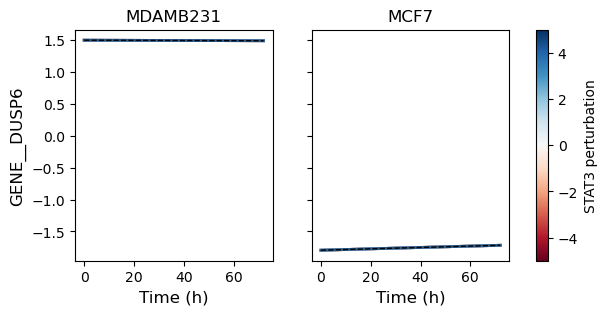

In [ ]:
# gradient color map (not white at 0 )
cmap = plt.cm.RdBu
norm = plt.Normalize(vmin=-5, vmax=5)
pert_levels = np.linspace(-5, 5, len(xt))

fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
for p, xtt in zip(pert_levels, xt):
    ax[0].plot(
        t.detach().cpu().numpy(),
        xtt,
        '-',
        alpha=0.5,
        color=cmap(norm(p)),
        linewidth=2,
    )
# add 0 perturbation line as a black line 
ax[0].plot(t.detach().cpu().numpy(), xt[5], 'k--', linewidth=1)

for p, xtt in zip(pert_levels, xt2):
    ax[1].plot(
        t.detach().cpu().numpy(),
        xtt,
        '-',
        alpha=0.5,
        color=cmap(norm(p)),
        linewidth=2,
    )
ax[1].plot(t.detach().cpu().numpy(), xt2[5], 'k--', linewidth=1)

ax[0].set_title(f'{cell1}', fontsize=12)
ax[1].set_title(f'{cell2}', fontsize=12)
ax[0].set_xlabel('Time (h)', fontsize=12)
ax[1].set_xlabel('Time (h)', fontsize=12)
ax[0].set_ylabel(f'{target_gene}', fontsize=12)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax).set_label(f'{perturb_gene.split("__")[1]} perturbation')

plt.show()


# Number of paths in subgraph 

1. Count the total number of paths from drug targets -> target gene 
2. Count the number of paths from drug targets -> target gene that are contained within the subgraph 
3. report the fraction of paths in subgraph explanation 


In [ ]:
data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)

In [ ]:
src1,dst1 = data.edge_index_dict['function', 'to', 'function']
src2,dst2 = data.edge_index_dict['input', 'to', 'function']
src3,dst3 = data.edge_index_dict['function', 'to', 'output']

all_edges1 = pd.DataFrame({'source': np.array(data.node_names_dict['function'])[src1], 'target': np.array(data.node_names_dict['function'])[dst1]})
all_edges2 = pd.DataFrame({'source': np.array(data.node_names_dict['input'])[src2], 'target': np.array(data.node_names_dict['function'])[dst2]})
all_edges3 = pd.DataFrame({'source': np.array(data.node_names_dict['function'])[src3], 'target': np.array(data.node_names_dict['output'])[dst3]})

all_edges = pd.concat([all_edges1, all_edges2, all_edges3])
G_full = nx.from_pandas_edgelist(all_edges, source='source', target='target', create_using=nx.DiGraph)

print('# nodes', len(G_full))
print('# edges', len(G_full.edges()))


# nodes 5280
# edges 22735


In [ ]:
G_subgraph = nx.from_pandas_edgelist(cres_agg.reset_index()[lambda x: x.prob_gsnn_score > 0.5], source='source', target='target', create_using=nx.DiGraph)

print('# nodes', len(G_subgraph))
print('# edges', len(G_subgraph.edges()))


NameError: name 'cres_agg' is not defined

In [ ]:
root_genes = 'DRUG__BRD-K12343256'
leaf_genes = 'GENE__DUSP6'
depth = 6

In [ ]:
all_paths = list(nx.all_simple_edge_paths(G_full, source=root_genes, target=leaf_genes, cutoff=depth))
print('# all paths', len(all_paths))
subgraph_paths = list(nx.all_simple_edge_paths(G_subgraph, source=root_genes, target=leaf_genes, cutoff=depth))
print('# subgraph paths', len(subgraph_paths))

# all paths 31
# subgraph paths 31


In [ ]:
print(f'Fraction of paths in subgraph -> {len(subgraph_paths) / len(all_paths):.2f} [{len(subgraph_paths)} / {len(all_paths)}]')
print() 

print('Fraction of edges in subgraph (by length): ') 

path_lengths_subgraph = [len(p) for p in subgraph_paths] 
path_lengths_full = [len(p) for p in all_paths] 

for i in range(4, depth+1):
    n_paths_subgraph = np.sum([p == i for p in path_lengths_subgraph])
    n_paths_full = np.sum([p == i for p in path_lengths_full])
    print(f'\tFraction of paths of length {i} -> {n_paths_subgraph / n_paths_full:.2f} [{n_paths_subgraph} / {n_paths_full}]')


Fraction of paths in subgraph -> 1.00 [31 / 31]

Fraction of edges in subgraph (by length): 
	Fraction of paths of length 4 -> nan [0 / 0]
	Fraction of paths of length 5 -> 1.00 [3 / 3]
	Fraction of paths of length 6 -> 1.00 [28 / 28]


/tmp/ipykernel_313016/3546800955.py:12: RuntimeWarning: invalid value encountered in scalar divide
  print(f'\tFraction of paths of length {i} -> {n_paths_subgraph / n_paths_full:.2f} [{n_paths_subgraph} / {n_paths_full}]')


In [ ]:
cres_agg.head() 

,,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
source,target,,,,,,,,,,,,,
COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBRM1_SMARCA2_SMARCA4_SMARCB1_SMARCC1_SMARCC2_SMARCD1_SMARCD2_SMARCD3_SMARCE1,PROTEIN__TP53,0.998056,0.0,0.666667,1.647027,0.0,0.666667,0.0,3.127626e-01,0.0,0.666667,0.0,1.647027,3.127626e-01
COMPLEX__APC_CDC20,PROTEIN__CCNB1,0.998093,0.0,0.666667,0.242703,0.0,0.666667,0.0,1.906124e-02,0.0,0.666667,0.0,0.242703,1.906124e-02
COMPLEX__BTRC_CUL1_SKP1,PROTEIN__WEE1,0.992269,0.0,0.666667,-0.003996,0.0,0.000000,0.5,-2.031624e-05,0.0,0.000000,0.5,0.003996,2.031624e-05
COMPLEX__CAMK2A_CAMK2B_CAMK2D_CAMK2G,PROTEIN__MAP3K7,0.991706,0.0,0.666667,0.000101,0.0,0.666667,0.0,-3.373623e-06,0.0,0.000000,0.5,0.000101,3.373623e-06
COMPLEX__CCNA2_CDK2,PROTEIN__MYBL2,0.994395,0.0,0.666667,0.000000,0.0,0.000000,0.0,1.937151e-07,0.0,0.666667,0.0,0.000000,1.937151e-07
